FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\kimi\\output\\circular_heatmap_ARGs.png'

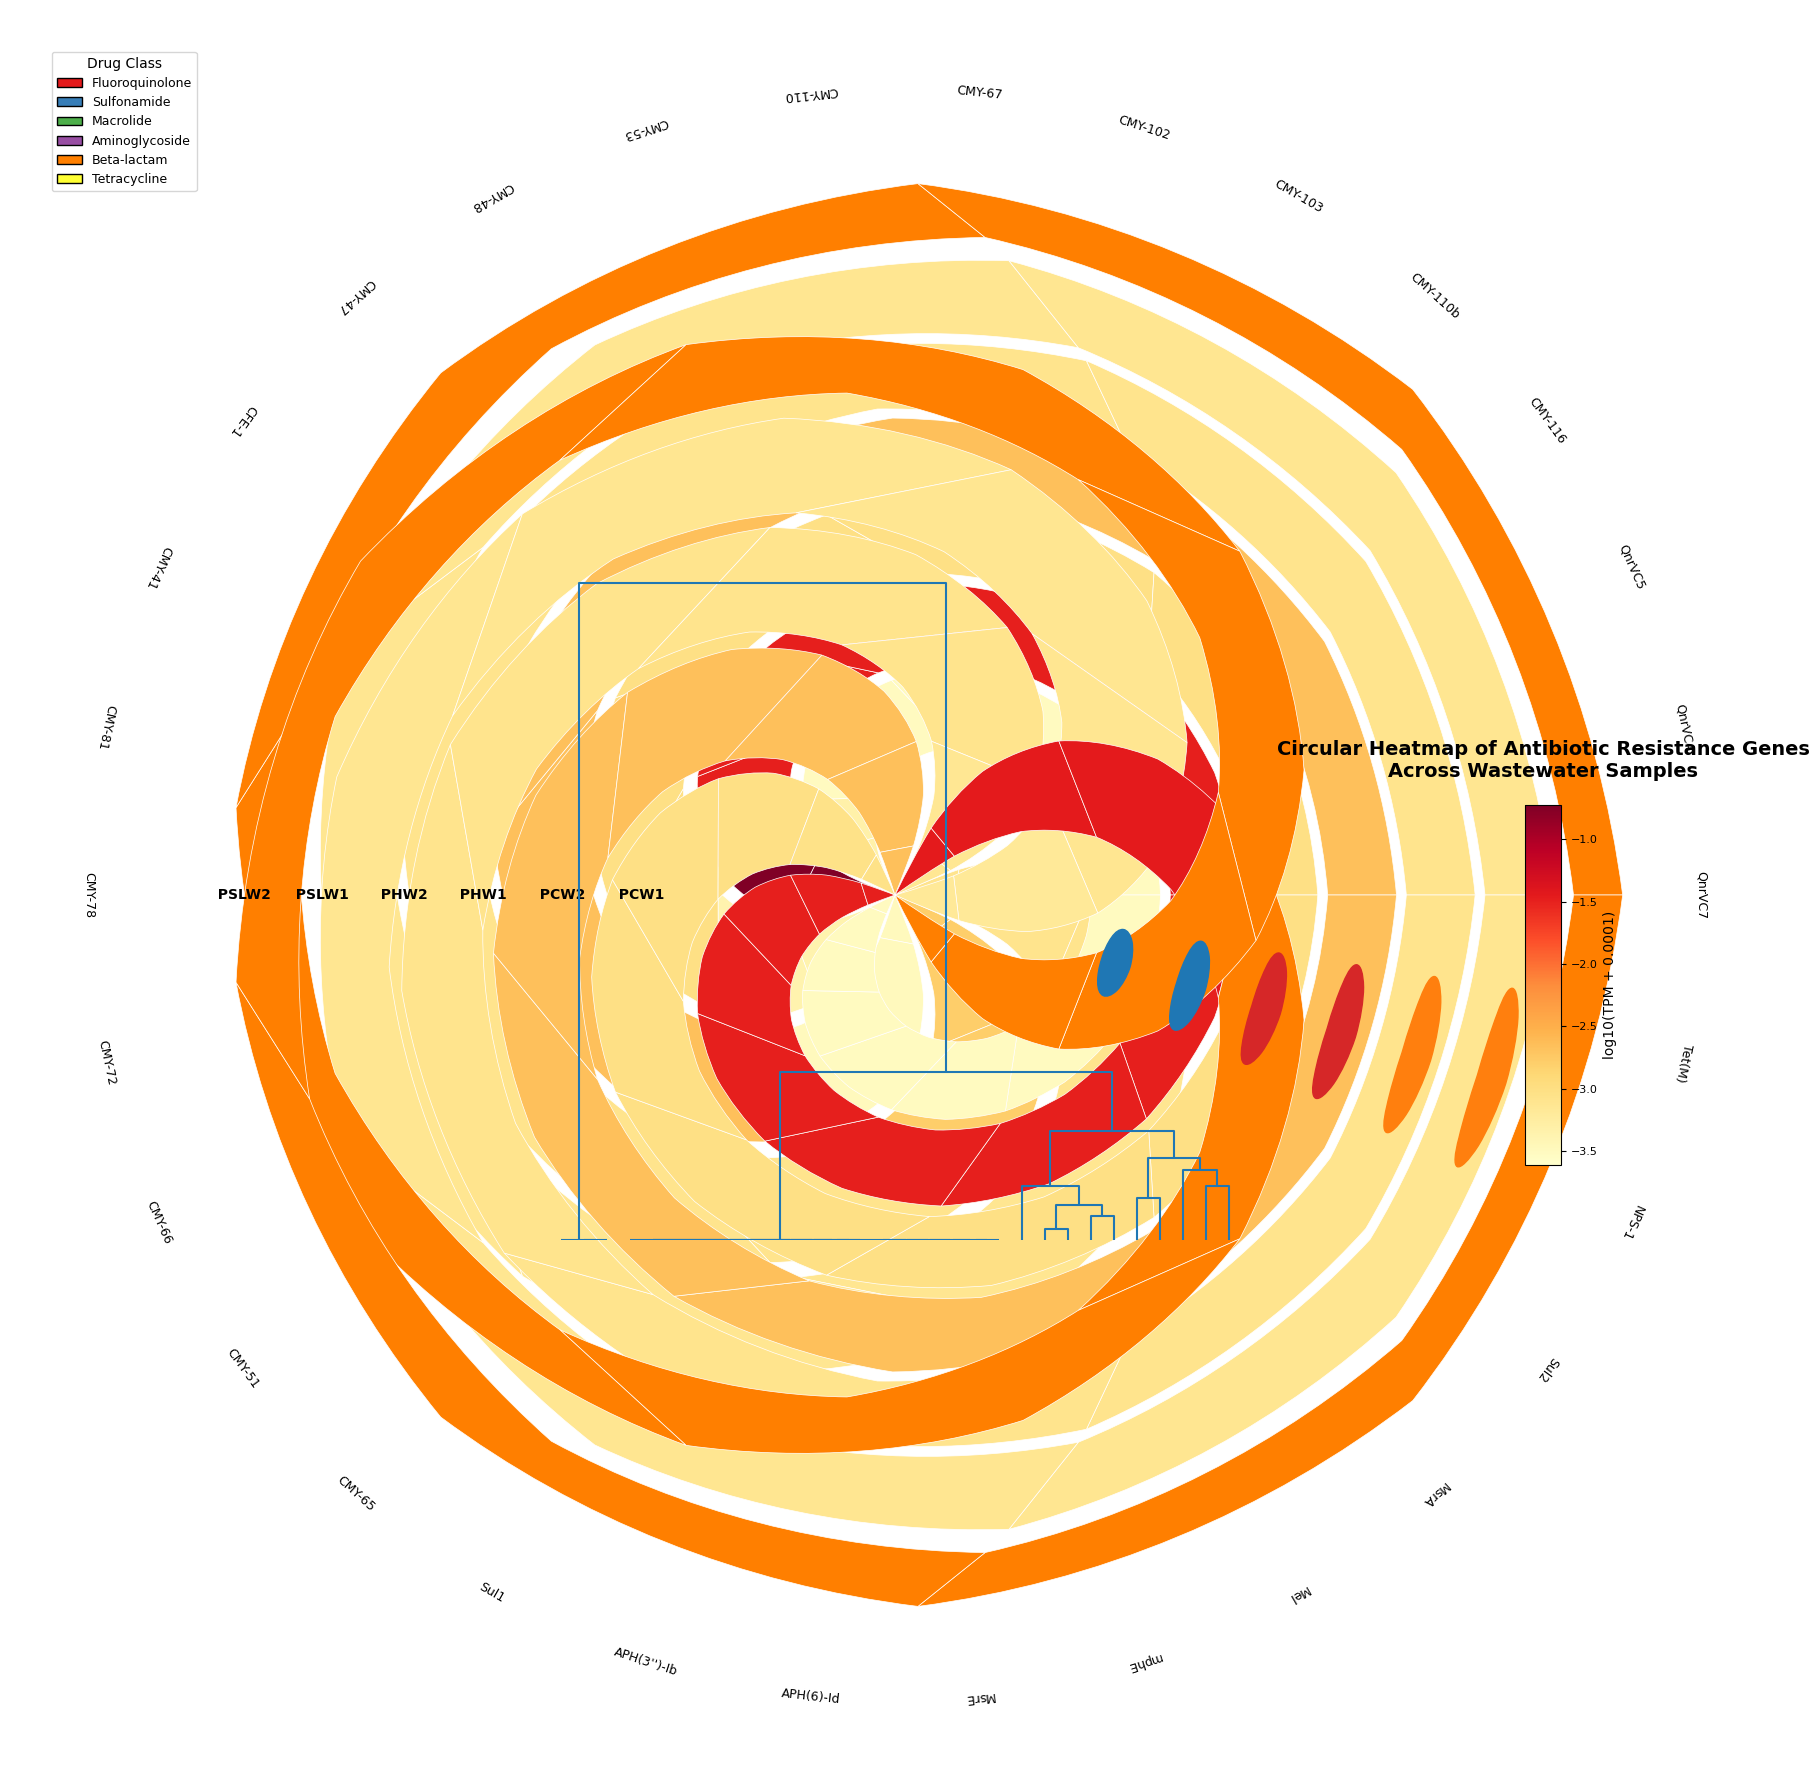

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
from matplotlib.patches import Circle

# ============================================
# DATA PREPARATION
# ============================================

# Create the data tables from the input
tpm_data = {
    'ARO ID': ['ARO:3002801', 'ARO:3002802', 'ARO:3003193', 'ARO:3000410', 'ARO:3003109', 
               'ARO:3002639', 'ARO:3002660', 'ARO:3003741', 'ARO:3000616', 'ARO:3004239',
               'ARO:3000615', 'ARO:3000412', 'ARO:3000186', 'ARO:3001856', 'ARO:3002052',
               'ARO:3002058', 'ARO:3002059', 'ARO:3002064', 'ARO:3002071', 'ARO:3002080',
               'ARO:3002115', 'ARO:3002116', 'ARO:3002123', 'ARO:3002129', 'ARO:3002062',
               'ARO:3002078', 'ARO:3002079', 'ARO:3002085', 'ARO:3002091', 'ARO:3002094'],
    'PCW1': [0.000376, 0.000376, 0.000376, 0.021487, 0.013957, 0.012811, 0.012633, 0.010854, 0.003148, 0.006824,
             0.002417, 0.015517, 0.002445, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216,
             0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216],
    'PCW2': [0.188758, 0.188758, 0.188758, 0.003363, 0.003239, 0.005890, 0.006391, 0.003249, 0.009021, 0.000441,
             0.006246, 0.006339, 0.008061, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594,
             0.032594, 0.032594, 0.032594, 0.032594, 0.032529, 0.032529, 0.032529, 0.032529, 0.032529, 0.032529],
    'PHW1': [0.000340, 0.000340, 0.000340, 0.032787, 0.038786, 0.030901, 0.028768, 0.033964, 0.020333, 0.020363,
             0.010609, 0.008632, 0.015840, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858,
             0.000858, 0.000858, 0.000858, 0.000858, 0.000799, 0.000799, 0.000799, 0.000799, 0.000799, 0.000799],
    'PHW2': [0.000231, 0.000231, 0.000231, 0.029880, 0.020847, 0.023709, 0.022522, 0.018690, 0.007125, 0.017552,
             0.005829, 0.006988, 0.010766, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123,
             0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123],
    'PSLW1': [0.001543, 0.001543, 0.001543, 0.007123, 0.003330, 0.006245, 0.005172, 0.002963, 0.023753, 0.001666,
              0.020411, 0.006030, 0.008550, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715,
              0.000715, 0.000715, 0.000715, 0.000715, 0.000641, 0.000641, 0.000641, 0.000641, 0.000641, 0.000641],
    'PSLW2': [0.000728, 0.000728, 0.000728, 0.005796, 0.003239, 0.003034, 0.003261, 0.002683, 0.000720, 0.000473,
              0.000906, 0.002773, 0.000145, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655,
              0.000655, 0.000655, 0.000655, 0.000655, 0.000565, 0.000565, 0.000565, 0.000565, 0.000565, 0.000565]
}

mapping_data = {
    'ARO ID': ['ARO:3002801', 'ARO:3002802', 'ARO:3003193', 'ARO:3000410', 'ARO:3003109',
               'ARO:3002639', 'ARO:3002660', 'ARO:3003741', 'ARO:3000616', 'ARO:3004239',
               'ARO:3000615', 'ARO:3000412', 'ARO:3000186', 'ARO:3001856', 'ARO:3002052',
               'ARO:3002058', 'ARO:3002059', 'ARO:3002064', 'ARO:3002071', 'ARO:3002080',
               'ARO:3002115', 'ARO:3002116', 'ARO:3002123', 'ARO:3002129', 'ARO:3002062',
               'ARO:3002078', 'ARO:3002079', 'ARO:3002085', 'ARO:3002091', 'ARO:3002094'],
    'Gene Name': ['QnrVC4', 'QnrVC5', 'QnrVC7', 'Sul1', 'MsrE', 'APH(3\'\')-Ib', 'APH(6)-Id', 
                  'mphE', 'Mel', 'NPS-1', 'MsrA', 'Sul2', 'Tet(M)', 'CFE-1', 'CMY-41', 'CMY-47',
                  'CMY-48', 'CMY-53', 'CMY-110', 'CMY-67', 'CMY-102', 'CMY-103', 'CMY-110b',
                  'CMY-116', 'CMY-51', 'CMY-65', 'CMY-66', 'CMY-72', 'CMY-78', 'CMY-81'],
    'Drug Class': ['Fluoroquinolone', 'Fluoroquinolone', 'Fluoroquinolone', 'Sulfonamide', 'Macrolide',
                   'Aminoglycoside', 'Aminoglycoside', 'Macrolide', 'Macrolide', 'Beta-lactam',
                   'Macrolide', 'Sulfonamide', 'Tetracycline', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam']
}

# Create DataFrames
tpm_df = pd.DataFrame(tpm_data)
mapping_df = pd.DataFrame(mapping_data)

# Merge dataframes
df = pd.merge(tpm_df, mapping_df, on='ARO ID')

# ============================================
# CONFIGURATION
# ============================================

# Sample sector colors
sample_sectors = {
    'PCW1': '#1F77B4',  # Community wastewater - Blue
    'PCW2': '#1F77B4',
    'PHW1': '#D62728',  # Hospital wastewater - Red
    'PHW2': '#D62728',
    'PSLW1': '#FF7F0E', # Slaughterhouse wastewater - Orange
    'PSLW2': '#FF7F0E'
}

# Drug class colors for the outer annotation track
drug_class_colors = {
    'Fluoroquinolone': '#E41A1C',
    'Sulfonamide': '#377EB8',
    'Macrolide': '#4DAF4A',
    'Aminoglycoside': '#984EA3',
    'Beta-lactam': '#FF7F00',
    'Tetracycline': '#FFFF33'
}

# Prepare data for clustering and visualization
sample_cols = ['PCW1', 'PCW2', 'PHW1', 'PHW2', 'PSLW1', 'PSLW2']
X = df[sample_cols].values

# Apply log10 transformation: log10(TPM + 0.0001)
X_log = np.log10(X + 0.0001)

# Perform hierarchical clustering on ARGs (rows)
linkage_matrix = linkage(X, method='average', metric='euclidean')

# Get the order of genes from clustering
dendro = dendrogram(linkage_matrix, no_plot=True)
leaf_order = dendro['leaves']

# Reorder dataframe according to clustering
df_ordered = df.iloc[leaf_order].reset_index(drop=True)
X_ordered = X_log[leaf_order]

# ============================================
# CREATE THE CIRCULAR HEATMAP
# ============================================

fig = plt.figure(figsize=(18, 18), facecolor='white')
ax = fig.add_subplot(111, projection='polar')
ax.set_facecolor('white')

# Parameters for the circular layout
n_genes = len(df_ordered)
n_samples = len(sample_cols)

# Angular positions for each gene (ARGs on the outer circumference)
theta = np.linspace(0, 2 * np.pi, n_genes, endpoint=False)

# Width of each angular segment
dtheta = 2 * np.pi / n_genes

# Inner and outer radii for each sample ring (from inner to outer)
sample_order = ['PCW1', 'PCW2', 'PHW1', 'PHW2', 'PSLW1', 'PSLW2']
inner_radii = [2.0, 2.8, 3.6, 4.4, 5.2, 6.0]
outer_radii = [2.7, 3.5, 4.3, 5.1, 5.9, 6.7]

# Create the colormap for TPM values (using YlOrRd)
cmap = plt.cm.YlOrRd
norm = Normalize(vmin=X_log.min(), vmax=X_log.max())

# Plot the heatmap rings
for i, gene_idx in enumerate(range(n_genes)):
    for j, sample in enumerate(sample_order):
        value = X_ordered[gene_idx, j]
        color = cmap(norm(value))
        
        # Create a wedge for each cell
        wedge = mpatches.Wedge(
            center=(0, 0),
            r=outer_radii[j],
            theta1=np.degrees(theta[i] - dtheta/2),
            theta2=np.degrees(theta[i] + dtheta/2),
            width=outer_radii[j] - inner_radii[j],
            facecolor=color,
            edgecolor='white',
            linewidth=0.5
        )
        ax.add_patch(wedge)

# ============================================
# ADD DRUG CLASS ANNOTATION TRACK
# ============================================

drug_class_inner = 6.9
drug_class_outer = 7.4

for i, gene_idx in enumerate(range(n_genes)):
    drug_class = df_ordered.iloc[gene_idx]['Drug Class']
    color = drug_class_colors[drug_class]
    
    wedge = mpatches.Wedge(
        center=(0, 0),
        r=drug_class_outer,
        theta1=np.degrees(theta[i] - dtheta/2),
        theta2=np.degrees(theta[i] + dtheta/2),
        width=drug_class_outer - drug_class_inner,
        facecolor=color,
        edgecolor='white',
        linewidth=0.5
    )
    ax.add_patch(wedge)

# ============================================
# ADD GENE NAME LABELS
# ============================================

label_radius = 8.2

for i, gene_idx in enumerate(range(n_genes)):
    gene_name = df_ordered.iloc[gene_idx]['Gene Name']
    angle = theta[i]
    angle_deg = np.degrees(angle)
    
    # Calculate rotation for radial alignment
    if 90 <= angle_deg <= 270:
        rotation = angle_deg + 180
    else:
        rotation = angle_deg
    
    ax.text(angle, label_radius, gene_name, 
            ha='center', va='center', fontsize=9, 
            rotation=rotation - 90,
            rotation_mode='anchor',
            fontweight='normal')

# ============================================
# ADD SAMPLE LABELS AND SECTOR COLOR INDICATORS
# ============================================

# Add sample labels on the left side
sample_label_radius = [2.35, 3.15, 3.95, 4.75, 5.55, 6.35]

for j, sample in enumerate(sample_order):
    # Add a colored circle to indicate sector
    circle = Circle((-0.3, sample_label_radius[j]), 0.15, 
                    color=sample_sectors[sample], 
                    zorder=10, clip_on=False, transform=ax.transData)
    ax.add_patch(circle)
    
    # Add sample name
    ax.text(np.pi, sample_label_radius[j], f'  {sample}', 
            ha='right', va='center', fontsize=10, fontweight='bold')

# ============================================
# ADD DENDROGRAM AT CENTER
# ============================================

# Create inset axes for dendrogram
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Calculate dendrogram positions
# We need to map the dendrogram to the center of the polar plot
# The dendrogram leaves should align with the angular positions

# Create a separate axes for dendrogram at center
ax_dendro = inset_axes(ax, width="30%", height="30%", loc='center',
                       bbox_to_anchor=(-0.15, -0.15, 1.3, 1.3),
                       bbox_transform=ax.transAxes)

# Plot dendrogram with orientation to match circular layout
dendro_plot = dendrogram(linkage_matrix, orientation='top', 
                         labels=df_ordered['Gene Name'].values,
                         leaf_rotation=90, ax=ax_dendro,
                         color_threshold=0)

ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.axis('off')

# ============================================
# ADD COLOR BAR FOR TPM VALUES
# ============================================

# Create colorbar axes
cbar_ax = fig.add_axes([0.85, 0.35, 0.02, 0.2])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('log10(TPM + 0.0001)', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# ============================================
# ADD DRUG CLASS LEGEND
# ============================================

legend_elements = [mpatches.Patch(facecolor=color, edgecolor='black', label=cls) 
                   for cls, color in drug_class_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98),
          title='Drug Class', fontsize=9, title_fontsize=10, frameon=True)

# ============================================
# FINALIZE PLOT
# ============================================

ax.set_ylim(0, 9)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

plt.title('Circular Heatmap of Antibiotic Resistance Genes\nAcross Wastewater Samples', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/mnt/kimi/output/circular_heatmap_ARGs.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('/mnt/kimi/output/circular_heatmap_ARGs.svg', bbox_inches='tight', facecolor='white')
plt.show()

print("Figure saved as PNG and SVG!")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\kimi\\output\\circular_heatmap_ARGs_v2.png'

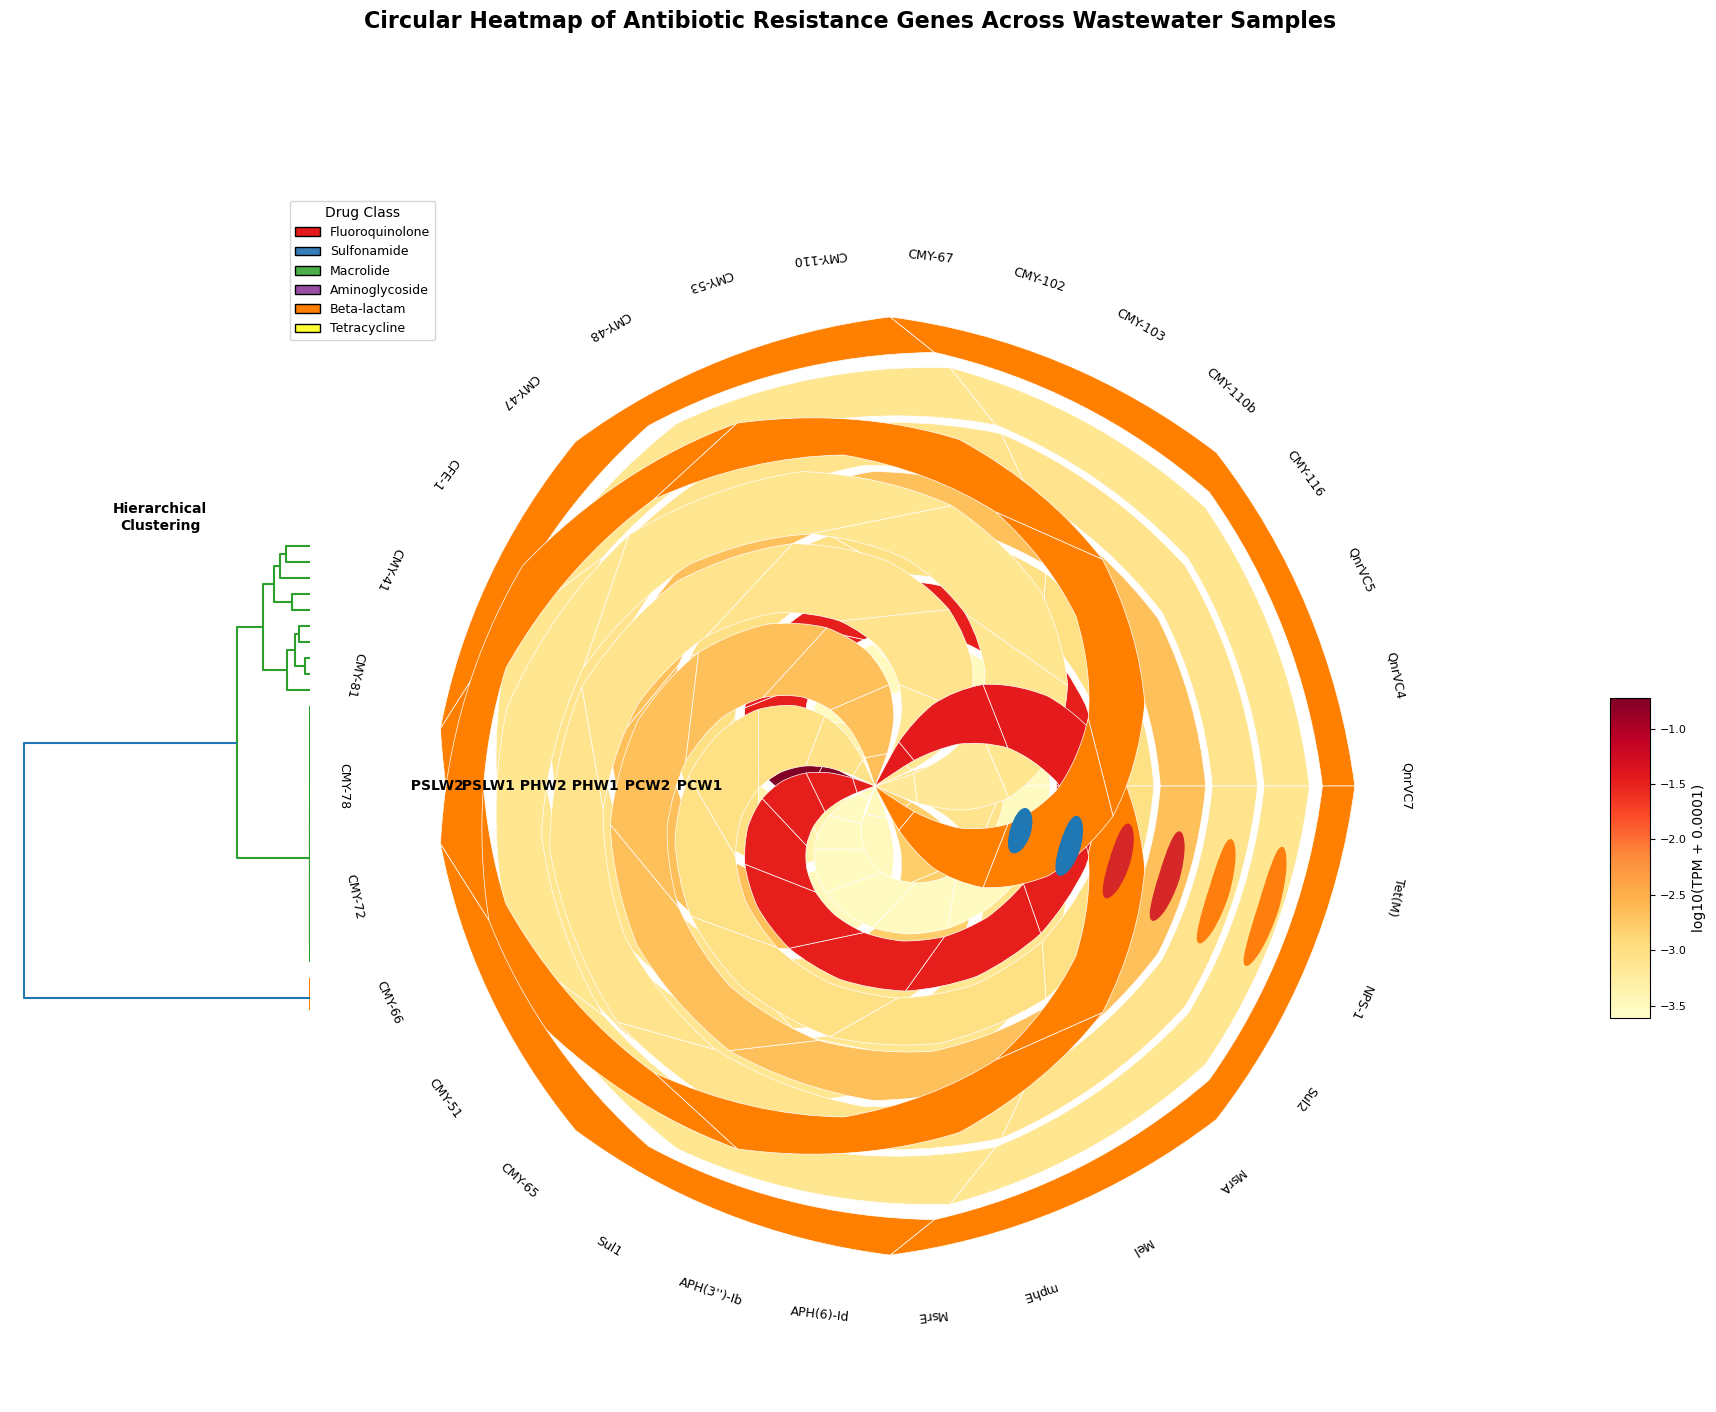

In [9]:

# Let's also create a cleaner version with better dendrogram integration
# and proper alignment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
from matplotlib.patches import Circle, Wedge

# Recreate data
tpm_data = {
    'ARO ID': ['ARO:3002801', 'ARO:3002802', 'ARO:3003193', 'ARO:3000410', 'ARO:3003109', 
               'ARO:3002639', 'ARO:3002660', 'ARO:3003741', 'ARO:3000616', 'ARO:3004239',
               'ARO:3000615', 'ARO:3000412', 'ARO:3000186', 'ARO:3001856', 'ARO:3002052',
               'ARO:3002058', 'ARO:3002059', 'ARO:3002064', 'ARO:3002071', 'ARO:3002080',
               'ARO:3002115', 'ARO:3002116', 'ARO:3002123', 'ARO:3002129', 'ARO:3002062',
               'ARO:3002078', 'ARO:3002079', 'ARO:3002085', 'ARO:3002091', 'ARO:3002094'],
    'PCW1': [0.000376, 0.000376, 0.000376, 0.021487, 0.013957, 0.012811, 0.012633, 0.010854, 0.003148, 0.006824,
             0.002417, 0.015517, 0.002445, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216,
             0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216, 0.000216],
    'PCW2': [0.188758, 0.188758, 0.188758, 0.003363, 0.003239, 0.005890, 0.006391, 0.003249, 0.009021, 0.000441,
             0.006246, 0.006339, 0.008061, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594, 0.032594,
             0.032594, 0.032594, 0.032594, 0.032594, 0.032529, 0.032529, 0.032529, 0.032529, 0.032529, 0.032529],
    'PHW1': [0.000340, 0.000340, 0.000340, 0.032787, 0.038786, 0.030901, 0.028768, 0.033964, 0.020333, 0.020363,
             0.010609, 0.008632, 0.015840, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858, 0.000858,
             0.000858, 0.000858, 0.000858, 0.000858, 0.000799, 0.000799, 0.000799, 0.000799, 0.000799, 0.000799],
    'PHW2': [0.000231, 0.000231, 0.000231, 0.029880, 0.020847, 0.023709, 0.022522, 0.018690, 0.007125, 0.017552,
             0.005829, 0.006988, 0.010766, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123,
             0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123, 0.002123],
    'PSLW1': [0.001543, 0.001543, 0.001543, 0.007123, 0.003330, 0.006245, 0.005172, 0.002963, 0.023753, 0.001666,
              0.020411, 0.006030, 0.008550, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715, 0.000715,
              0.000715, 0.000715, 0.000715, 0.000715, 0.000641, 0.000641, 0.000641, 0.000641, 0.000641, 0.000641],
    'PSLW2': [0.000728, 0.000728, 0.000728, 0.005796, 0.003239, 0.003034, 0.003261, 0.002683, 0.000720, 0.000473,
              0.000906, 0.002773, 0.000145, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655, 0.000655,
              0.000655, 0.000655, 0.000655, 0.000655, 0.000565, 0.000565, 0.000565, 0.000565, 0.000565, 0.000565]
}

mapping_data = {
    'ARO ID': ['ARO:3002801', 'ARO:3002802', 'ARO:3003193', 'ARO:3000410', 'ARO:3003109',
               'ARO:3002639', 'ARO:3002660', 'ARO:3003741', 'ARO:3000616', 'ARO:3004239',
               'ARO:3000615', 'ARO:3000412', 'ARO:3000186', 'ARO:3001856', 'ARO:3002052',
               'ARO:3002058', 'ARO:3002059', 'ARO:3002064', 'ARO:3002071', 'ARO:3002080',
               'ARO:3002115', 'ARO:3002116', 'ARO:3002123', 'ARO:3002129', 'ARO:3002062',
               'ARO:3002078', 'ARO:3002079', 'ARO:3002085', 'ARO:3002091', 'ARO:3002094'],
    'Gene Name': ['QnrVC4', 'QnrVC5', 'QnrVC7', 'Sul1', 'MsrE', 'APH(3\'\')-Ib', 'APH(6)-Id', 
                  'mphE', 'Mel', 'NPS-1', 'MsrA', 'Sul2', 'Tet(M)', 'CFE-1', 'CMY-41', 'CMY-47',
                  'CMY-48', 'CMY-53', 'CMY-110', 'CMY-67', 'CMY-102', 'CMY-103', 'CMY-110b',
                  'CMY-116', 'CMY-51', 'CMY-65', 'CMY-66', 'CMY-72', 'CMY-78', 'CMY-81'],
    'Drug Class': ['Fluoroquinolone', 'Fluoroquinolone', 'Fluoroquinolone', 'Sulfonamide', 'Macrolide',
                   'Aminoglycoside', 'Aminoglycoside', 'Macrolide', 'Macrolide', 'Beta-lactam',
                   'Macrolide', 'Sulfonamide', 'Tetracycline', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam',
                   'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam', 'Beta-lactam']
}

tpm_df = pd.DataFrame(tpm_data)
mapping_df = pd.DataFrame(mapping_data)
df = pd.merge(tpm_df, mapping_df, on='ARO ID')

# Configuration
sample_sectors = {
    'PCW1': '#1F77B4', 'PCW2': '#1F77B4',
    'PHW1': '#D62728', 'PHW2': '#D62728',
    'PSLW1': '#FF7F0E', 'PSLW2': '#FF7F0E'
}

drug_class_colors = {
    'Fluoroquinolone': '#E41A1C',
    'Sulfonamide': '#377EB8',
    'Macrolide': '#4DAF4A',
    'Aminoglycoside': '#984EA3',
    'Beta-lactam': '#FF7F00',
    'Tetracycline': '#FFFF33'
}

sample_cols = ['PCW1', 'PCW2', 'PHW1', 'PHW2', 'PSLW1', 'PSLW2']
X = df[sample_cols].values
X_log = np.log10(X + 0.0001)

# Clustering
linkage_matrix = linkage(X, method='average', metric='euclidean')
dendro = dendrogram(linkage_matrix, no_plot=True)
leaf_order = dendro['leaves']
df_ordered = df.iloc[leaf_order].reset_index(drop=True)
X_ordered = X_log[leaf_order]

# Create figure with subplots for better layout
fig = plt.figure(figsize=(20, 16), facecolor='white')

# Main polar plot
ax_main = fig.add_subplot(111, projection='polar')
ax_main.set_facecolor('white')

n_genes = len(df_ordered)
theta = np.linspace(0, 2 * np.pi, n_genes, endpoint=False)
dtheta = 2 * np.pi / n_genes

sample_order = ['PCW1', 'PCW2', 'PHW1', 'PHW2', 'PSLW1', 'PSLW2']
inner_radii = [2.0, 2.8, 3.6, 4.4, 5.2, 6.0]
outer_radii = [2.7, 3.5, 4.3, 5.1, 5.9, 6.7]

cmap = plt.cm.YlOrRd
norm = Normalize(vmin=X_log.min(), vmax=X_log.max())

# Plot heatmap rings
for i in range(n_genes):
    for j, sample in enumerate(sample_order):
        value = X_ordered[i, j]
        color = cmap(norm(value))
        wedge = Wedge(
            center=(0, 0),
            r=outer_radii[j],
            theta1=np.degrees(theta[i] - dtheta/2),
            theta2=np.degrees(theta[i] + dtheta/2),
            width=outer_radii[j] - inner_radii[j],
            facecolor=color,
            edgecolor='white',
            linewidth=0.5
        )
        ax_main.add_patch(wedge)

# Drug class track
drug_class_inner = 6.9
drug_class_outer = 7.4

for i in range(n_genes):
    drug_class = df_ordered.iloc[i]['Drug Class']
    color = drug_class_colors[drug_class]
    wedge = Wedge(
        center=(0, 0),
        r=drug_class_outer,
        theta1=np.degrees(theta[i] - dtheta/2),
        theta2=np.degrees(theta[i] + dtheta/2),
        width=drug_class_outer - drug_class_inner,
        facecolor=color,
        edgecolor='white',
        linewidth=0.5
    )
    ax_main.add_patch(wedge)

# Gene name labels
label_radius = 8.2
for i in range(n_genes):
    gene_name = df_ordered.iloc[i]['Gene Name']
    angle = theta[i]
    angle_deg = np.degrees(angle)
    
    if 90 <= angle_deg <= 270:
        rotation = angle_deg + 180
    else:
        rotation = angle_deg
    
    ax_main.text(angle, label_radius, gene_name, 
            ha='center', va='center', fontsize=9, 
            rotation=rotation - 90,
            rotation_mode='anchor',
            fontweight='normal')

# Sample labels
sample_label_radius = [2.35, 3.15, 3.95, 4.75, 5.55, 6.35]
for j, sample in enumerate(sample_order):
    circle = Circle((-0.3, sample_label_radius[j]), 0.15, 
                    color=sample_sectors[sample], 
                    zorder=10, clip_on=False, transform=ax_main.transData)
    ax_main.add_patch(circle)
    ax_main.text(np.pi, sample_label_radius[j], f'  {sample}', 
            ha='right', va='center', fontsize=10, fontweight='bold')

# Create separate dendrogram subplot
# Position it at the center-left
ax_dendro = fig.add_axes([0.08, 0.35, 0.15, 0.3])
with plt.rc_context({'lines.linewidth': 1.5}):
    dendro_plot = dendrogram(linkage_matrix, orientation='left', 
                             labels=df_ordered['Gene Name'].values,
                             leaf_font_size=8, ax=ax_dendro)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.axis('off')
ax_dendro.set_title('Hierarchical\nClustering', fontsize=10, fontweight='bold')

# Colorbar
cbar_ax = fig.add_axes([0.88, 0.35, 0.02, 0.2])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('log10(TPM + 0.0001)', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Drug class legend
legend_elements = [mpatches.Patch(facecolor=color, edgecolor='black', label=cls) 
                   for cls, color in drug_class_colors.items()]
ax_main.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98),
          title='Drug Class', fontsize=9, title_fontsize=10, frameon=True)

# Finalize main plot
ax_main.set_ylim(0, 9.5)
ax_main.set_xticks([])
ax_main.set_yticks([])
ax_main.spines['polar'].set_visible(False)

plt.suptitle('Circular Heatmap of Antibiotic Resistance Genes Across Wastewater Samples', 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('/mnt/kimi/output/circular_heatmap_ARGs_v2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('/mnt/kimi/output/circular_heatmap_ARGs_v2.svg', bbox_inches='tight', facecolor='white')
plt.show()

print("Publication-ready figure saved!")
